In [1]:
!pip install tf-nightly-gpu-2.0-preview
import tensorflow as tf

  Preparing metadata (setup.py) ... done
  Created wheel for tf-nightly-gpu-2.0-preview: filename=tf_nightly_gpu_2_0_preview-0.0.0.1-py3-none-any.whl size=1542 sha256=85f651b2c9974a86a89a960244d9ab41b255c7006598e92a269eb23edde1bc96
  Stored in directory: /root/.cache/pip/wheels/50/39/2e/a9e8955905c7218ac8015dfd4fa44450c6c2119212c464a01c
Successfully built tf-nightly-gpu-2.0-preview


2026-03-01 08:05:55.646900: E external/local_xla/xla/stream_executor/cuda/cuda_fft.cc:467] Unable to register cuFFT factory: Attempting to register factory for plugin cuFFT when one has already been registered
E0000 00:00:1772352355.977415      23 cuda_dnn.cc:8579] Unable to register cuDNN factory: Attempting to register factory for plugin cuDNN when one has already been registered
E0000 00:00:1772352356.073964      23 cuda_blas.cc:1407] Unable to register cuBLAS factory: Attempting to register factory for plugin cuBLAS when one has already been registered
W0000 00:00:1772352356.897646      23 computation_placer.cc:177] computation placer already registered. Please check linkage and avoid linking the same target more than once.
W0000 00:00:1772352356.897699      23 computation_placer.cc:177] computation placer already registered. Please check linkage and avoid linking the same target more than once.
W0000 00:00:1772352356.897702      23 computation_placer.cc:177] computation placer alr

In [2]:
import tensorflow as tf
import matplotlib.pyplot as plt
import seaborn as sns
import numpy as np
import pandas as pd
import os
import pickle
from sklearn.metrics import classification_report, confusion_matrix
from sklearn.calibration import calibration_curve

In [3]:
# -------------------------------
# GPU Configuration
# -------------------------------
device_name = tf.test.gpu_device_name()
if device_name != '/device:GPU:0':
    raise SystemError('GPU device not found')
print('✅ Found GPU at: {}'.format(device_name))

if tf.config.list_physical_devices('GPU'):
    print("✅ GPU is available and being used.")
else:
    print("❌ No GPU found. Check Kaggle settings.")

✅ Found GPU at: /device:GPU:0
✅ GPU is available and being used.


I0000 00:00:1772352377.703174      23 gpu_device.cc:2019] Created device /device:GPU:0 with 13757 MB memory:  -> device: 0, name: Tesla T4, pci bus id: 0000:00:04.0, compute capability: 7.5
I0000 00:00:1772352377.709731      23 gpu_device.cc:2019] Created device /device:GPU:1 with 13757 MB memory:  -> device: 1, name: Tesla T4, pci bus id: 0000:00:05.0, compute capability: 7.5


In [4]:
# -------------------------------
# Configuration
# -------------------------------
CONFIG = {
    'image_size': (224, 224),
    'batch_size': 32,
    'epochs': 40,
    'learning_rate': 0.0005,
    'num_classes': 4,
    'seed': 42,
    'ensemble_weights': 'learned'  # 'learned', 'equal', or 'weighted'
}

In [5]:
# Dataset paths
train_path = "/kaggle/input/epics-lung-disease-dataset/new-lung-disease-dataset/train"
val_path = "/kaggle/input/epics-lung-disease-dataset/new-lung-disease-dataset/val"
test_path = "/kaggle/input/epics-lung-disease-dataset/new-lung-disease-dataset/test"

In [6]:
# -------------------------------
# Data Visualization Functions
# -------------------------------
def analyze_dataset(dataset_path, dataset_name):
    """Analyze class distribution in dataset"""
    class_counts = {}
    class_names = sorted([d for d in os.listdir(dataset_path) if os.path.isdir(os.path.join(dataset_path, d))])
    
    for class_name in class_names:
        class_dir = os.path.join(dataset_path, class_name)
        if os.path.isdir(class_dir):
            class_counts[class_name] = len(os.listdir(class_dir))
    
    print(f"\n📊 {dataset_name} Class Distribution:")
    for class_name, count in class_counts.items():
        print(f"   {class_name}: {count} images")
    
    # Plot
    plt.figure(figsize=(10, 6))
    bars = plt.bar(class_counts.keys(), class_counts.values(), color='skyblue')
    plt.xlabel("Disease Classes")
    plt.ylabel("Number of Images")
    plt.title(f"{dataset_name} - Class Distribution")
    plt.xticks(rotation=45)
    
    # Add value labels on bars
    for bar in bars:
        height = bar.get_height()
        plt.text(bar.get_x() + bar.get_width()/2., height,
                f'{int(height)}', ha='center', va='bottom')
    
    plt.tight_layout()
    plt.show()
    
    return class_counts, class_names

In [7]:
def plot_sample_images(dataset, class_names, num_samples=8):
    """Plot sample images from dataset"""
    plt.figure(figsize=(12, 8))
    for images, labels in dataset.take(1):
        for i in range(min(num_samples, len(images))):
            plt.subplot(2, 4, i+1)
            plt.imshow(images[i].numpy().astype("uint8"))
            true_label = class_names[tf.argmax(labels[i])]
            plt.title(f"True: {true_label}")
            plt.axis('off')
    plt.tight_layout()
    plt.show()


📊 Training Set Class Distribution:
   Corona Virus Disease: 1218 images
   Normal: 1207 images
   Pneumonia: 1201 images
   Tuberculosis: 1220 images


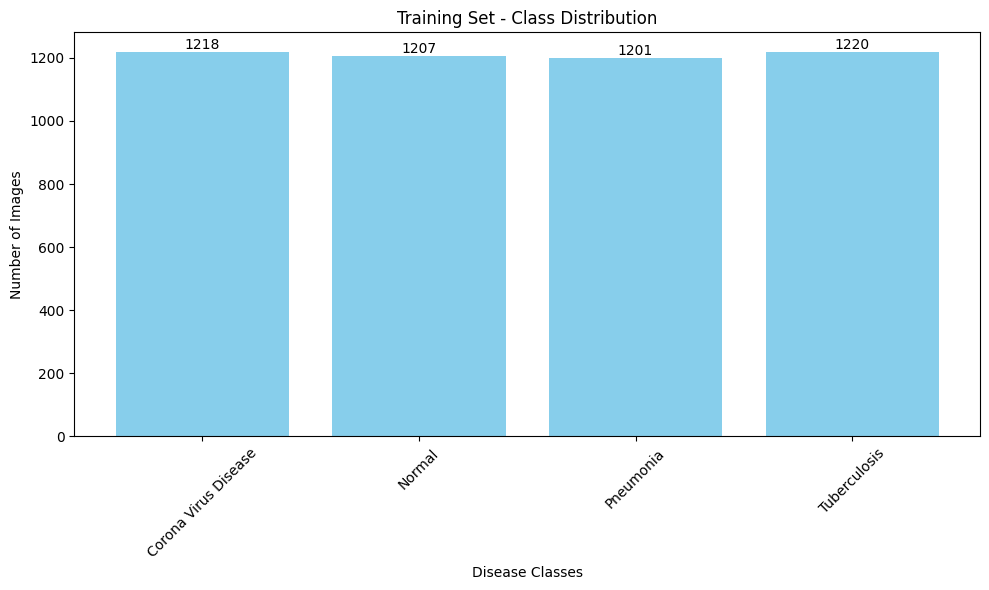


📊 Validation Set Class Distribution:
   Corona Virus Disease: 406 images
   Normal: 402 images
   Pneumonia: 406 images
   Tuberculosis: 406 images


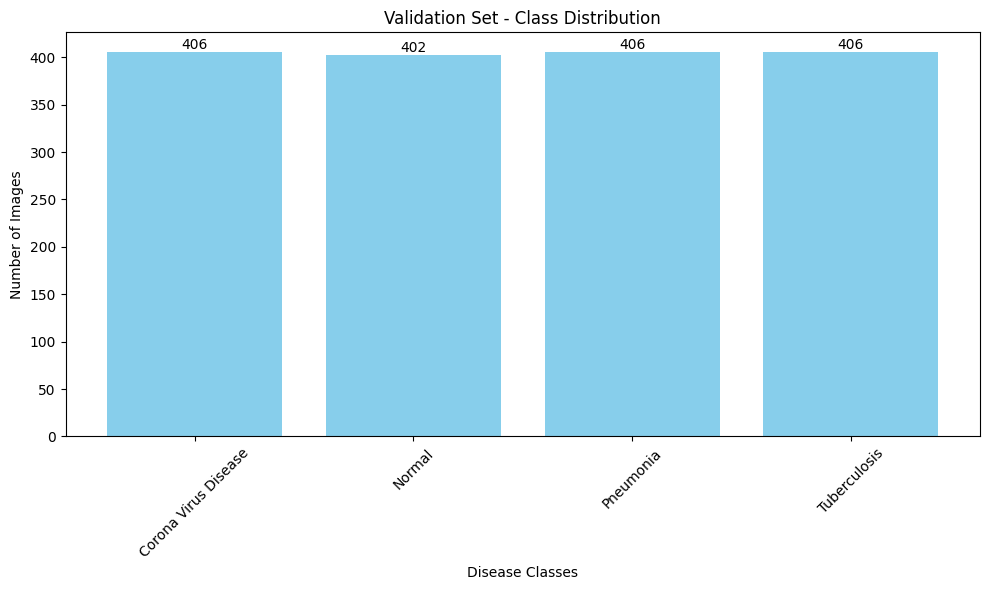


📊 Test Set Class Distribution:
   Corona Virus Disease: 407 images
   Normal: 404 images
   Pneumonia: 402 images
   Tuberculosis: 408 images


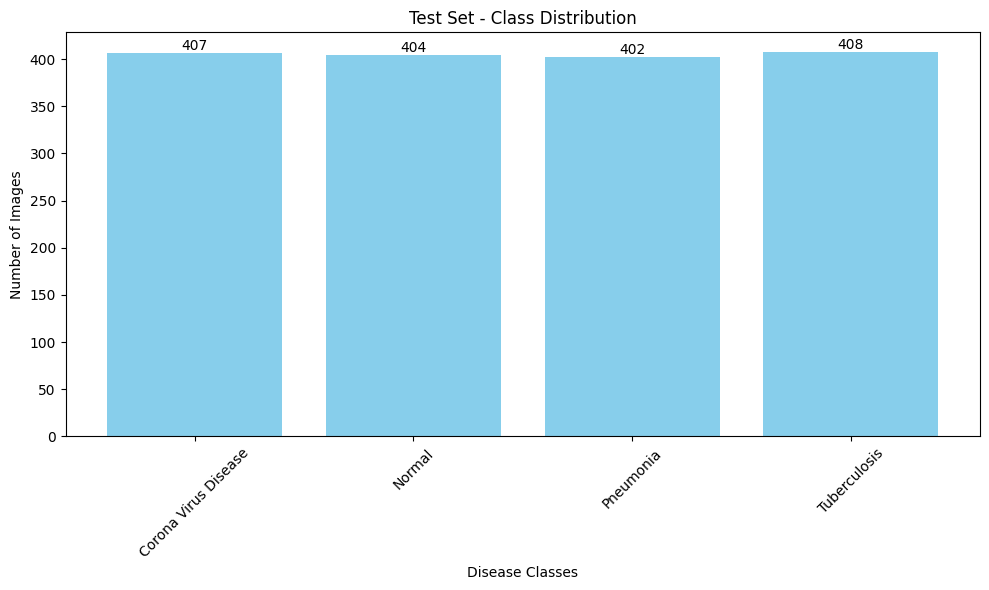

In [8]:
train_counts, class_names = analyze_dataset(train_path, "Training Set")
val_counts, _ = analyze_dataset(val_path, "Validation Set")
test_counts, _ = analyze_dataset(test_path, "Test Set")

In [9]:
print(f"\n🎯 Class Names: {class_names}")
CONFIG['num_classes'] = len(class_names)


🎯 Class Names: ['Corona Virus Disease', 'Normal', 'Pneumonia', 'Tuberculosis']


In [10]:
# -------------------------------
# Data Preparation
# -------------------------------
def load_datasets():
    """Load training, validation and test datasets"""
    print("\n📁 Loading and preparing datasets...")
    
    # Load datasets using image_dataset_from_directory
    training_set = tf.keras.utils.image_dataset_from_directory(
        train_path,
        labels="inferred",
        label_mode="categorical",
        color_mode="rgb",
        batch_size=CONFIG['batch_size'],
        image_size=CONFIG['image_size'],
        shuffle=True,
        seed=CONFIG['seed'],
        interpolation="bilinear"
    )

    validation_set = tf.keras.utils.image_dataset_from_directory(
        val_path,
        labels="inferred",
        label_mode="categorical",
        color_mode="rgb",
        batch_size=CONFIG['batch_size'],
        image_size=CONFIG['image_size'],
        shuffle=True,
        seed=CONFIG['seed'],
        interpolation="bilinear"
    )

    test_set = tf.keras.utils.image_dataset_from_directory(
        test_path,
        labels="inferred",
        label_mode="categorical",
        color_mode="rgb",
        batch_size=CONFIG['batch_size'],
        image_size=CONFIG['image_size'],
        shuffle=False,  # Important for evaluation
        seed=CONFIG['seed'],
        interpolation="bilinear"
    )
    
    return training_set, validation_set, test_set

In [11]:
training_set, validation_set, test_set = load_datasets()
    
# Display dataset information
print(f"📁 Training batches: {len(training_set)}")
print(f"📁 Validation batches: {len(validation_set)}")
print(f"📁 Test batches: {len(test_set)}")


📁 Loading and preparing datasets...
Found 4846 files belonging to 4 classes.


I0000 00:00:1772352380.129917      23 gpu_device.cc:2019] Created device /job:localhost/replica:0/task:0/device:GPU:0 with 13757 MB memory:  -> device: 0, name: Tesla T4, pci bus id: 0000:00:04.0, compute capability: 7.5
I0000 00:00:1772352380.131361      23 gpu_device.cc:2019] Created device /job:localhost/replica:0/task:0/device:GPU:1 with 13757 MB memory:  -> device: 1, name: Tesla T4, pci bus id: 0000:00:05.0, compute capability: 7.5


Found 1620 files belonging to 4 classes.
Found 1621 files belonging to 4 classes.
📁 Training batches: 152
📁 Validation batches: 51
📁 Test batches: 51


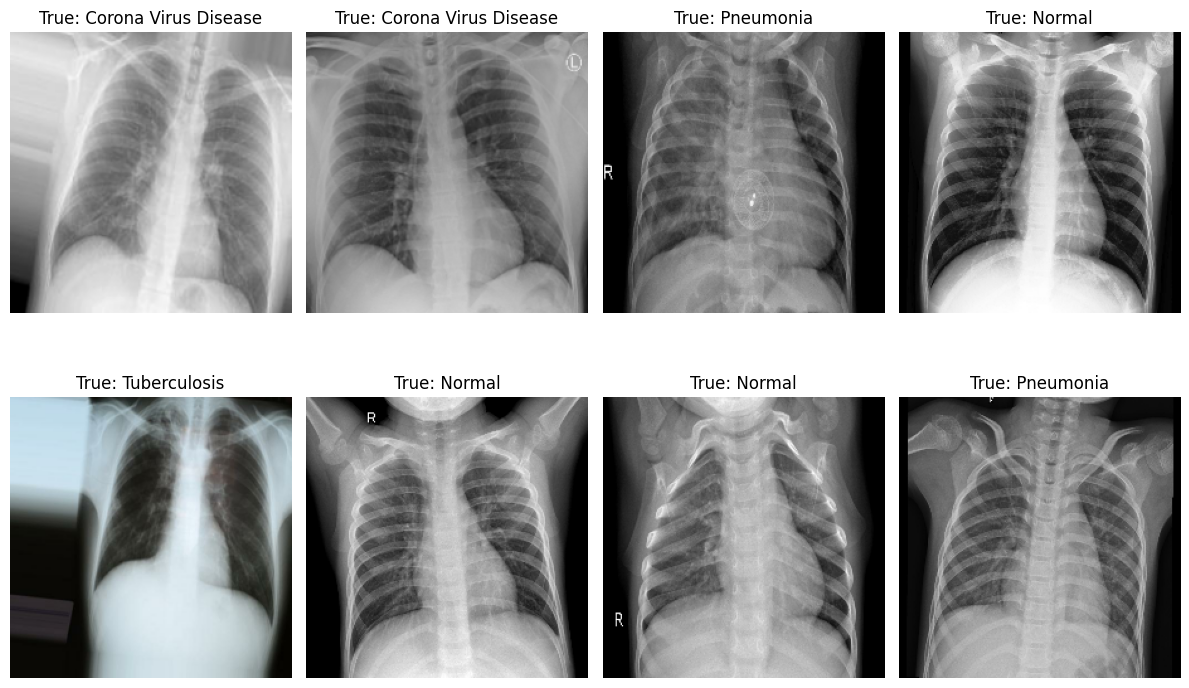

In [12]:
 # Plot sample images
plot_sample_images(training_set, class_names)

In [13]:
# -------------------------------
# Individual Model Architectures
# -------------------------------
def create_model_1_efficientnet():
    """Create EfficientNetB0 model (Model 1)"""
    print("\n🏗️ Creating Model 1: EfficientNetB0...")
    
    inputs = tf.keras.Input(shape=(*CONFIG['image_size'], 3))
    
    # Preprocessing
    x = tf.keras.applications.efficientnet.preprocess_input(inputs)
    
    # Base model
    base_model = tf.keras.applications.EfficientNetB0(
        input_shape=(*CONFIG['image_size'], 3),
        include_top=False,
        weights='imagenet',
        pooling='avg'
    )
    base_model.trainable = False
    
    # Feature extraction
    features = base_model(x, training=False)
    
    # Model-specific processing
    features = tf.keras.layers.Dropout(0.3)(features)
    features = tf.keras.layers.Dense(256, activation='relu')(features)
    features = tf.keras.layers.BatchNormalization()(features)
    
    model = tf.keras.Model(inputs=inputs, outputs=features, name='EfficientNetB0_Stream')
    
    print(f"   Model 1: EfficientNetB0")
    print(f"   Feature dimension: {features.shape[-1]}")
    
    return model

In [14]:
def create_model_2_mobilenet():
    """Create MobileNetV2 model (Model 2)"""
    print("\n🏗️ Creating Model 2: MobileNetV2...")
    
    inputs = tf.keras.Input(shape=(*CONFIG['image_size'], 3))
    
    # Preprocessing
    x = tf.keras.applications.mobilenet_v2.preprocess_input(inputs)
    
    # Base model
    base_model = tf.keras.applications.MobileNetV2(
        input_shape=(*CONFIG['image_size'], 3),
        include_top=False,
        weights='imagenet',
        pooling='avg'
    )
    base_model.trainable = False
    
    # Feature extraction
    features = base_model(x, training=False)
    
    # Model-specific processing
    features = tf.keras.layers.Dropout(0.3)(features)
    features = tf.keras.layers.Dense(256, activation='relu')(features)
    features = tf.keras.layers.BatchNormalization()(features)
    
    model = tf.keras.Model(inputs=inputs, outputs=features, name='MobileNetV2_Stream')
    
    print(f"   Model 2: MobileNetV2")
    print(f"   Feature dimension: {features.shape[-1]}")
    
    return model

In [15]:
def create_model_3_resnet():
    """Create ResNet50 model (Model 3)"""
    print("\n🏗️ Creating Model 3: ResNet50...")
    
    inputs = tf.keras.Input(shape=(*CONFIG['image_size'], 3))
    
    # Preprocessing
    x = tf.keras.applications.resnet.preprocess_input(inputs)
    
    # Base model
    base_model = tf.keras.applications.ResNet50(
        input_shape=(*CONFIG['image_size'], 3),
        include_top=False,
        weights='imagenet',
        pooling='avg'
    )
    base_model.trainable = False
    
    # Feature extraction
    features = base_model(x, training=False)
    
    # Model-specific processing
    features = tf.keras.layers.Dropout(0.3)(features)
    features = tf.keras.layers.Dense(256, activation='relu')(features)
    features = tf.keras.layers.BatchNormalization()(features)
    
    model = tf.keras.Model(inputs=inputs, outputs=features, name='ResNet50_Stream')
    
    print(f"   Model 3: ResNet50")
    print(f"   Feature dimension: {features.shape[-1]}")
    
    return model

In [16]:
def create_model_4_custom_cnn():
    """Create Custom CNN model (Alternative Model 4)"""
    print("\n🏗️ Creating Alternative Model: Custom CNN...")
    
    inputs = tf.keras.Input(shape=(*CONFIG['image_size'], 3))
    
    # Custom CNN architecture
    x = tf.keras.layers.Conv2D(32, (3, 3), activation='relu', padding='same')(inputs)
    x = tf.keras.layers.BatchNormalization()(x)
    x = tf.keras.layers.MaxPooling2D(2, 2)(x)
    x = tf.keras.layers.Dropout(0.2)(x)
    
    x = tf.keras.layers.Conv2D(64, (3, 3), activation='relu', padding='same')(x)
    x = tf.keras.layers.BatchNormalization()(x)
    x = tf.keras.layers.MaxPooling2D(2, 2)(x)
    x = tf.keras.layers.Dropout(0.3)(x)
    
    x = tf.keras.layers.Conv2D(128, (3, 3), activation='relu', padding='same')(x)
    x = tf.keras.layers.BatchNormalization()(x)
    x = tf.keras.layers.MaxPooling2D(2, 2)(x)
    x = tf.keras.layers.Dropout(0.4)(x)
    
    x = tf.keras.layers.GlobalAveragePooling2D()(x)
    features = tf.keras.layers.Dense(256, activation='relu')(x)
    
    model = tf.keras.Model(inputs=inputs, outputs=features, name='CustomCNN_Stream')
    
    print(f"   Alternative Model: Custom CNN")
    print(f"   Feature dimension: {features.shape[-1]}")
    
    return model


In [17]:
# -------------------------------
# Ensemble Model Architecture
# -------------------------------
def create_ensemble_model(model_combination='default'):
    """Create ensemble model combining multiple architectures"""
    print(f"\n🎯 Creating Ensemble Model...")
    
    # Choose which models to include in ensemble
    if model_combination == 'default':
        print("   Using default ensemble: EfficientNetB0 + MobileNetV2 + ResNet50")
        model1 = create_model_1_efficientnet()
        model2 = create_model_2_mobilenet()
        model3 = create_model_3_resnet()
        model_names = ['EfficientNetB0', 'MobileNetV2', 'ResNet50']
    elif model_combination == 'custom':
        print("   Using custom ensemble: MobileNetV2 + ResNet50 + Custom CNN")
        model1 = create_model_2_mobilenet()
        model2 = create_model_3_resnet()
        model3 = create_model_4_custom_cnn()
        model_names = ['MobileNetV2', 'ResNet50', 'Custom CNN']
    else:
        raise ValueError(f"Unknown model combination: {model_combination}")
    
    # Shared input
    inputs = tf.keras.Input(shape=(*CONFIG['image_size'], 3))
    
    # Get features from each model
    print("\n   Extracting features from each model...")
    features1 = model1(inputs)
    features2 = model2(inputs)
    features3 = model3(inputs)
    
    # Concatenate all features
    print("   Concatenating features...")
    concatenated = tf.keras.layers.Concatenate()([features1, features2, features3])
    
    print(f"   Combined feature dimension: {concatenated.shape[-1]}")
    
    # Meta-classifier (learns to combine features)
    print("\n   Building meta-classifier...")
    x = tf.keras.layers.Dropout(0.4)(concatenated)
    
    # Dense layers for combination
    x = tf.keras.layers.Dense(512, activation='relu')(x)
    x = tf.keras.layers.BatchNormalization()(x)
    x = tf.keras.layers.Dropout(0.5)(x)
    
    x = tf.keras.layers.Dense(256, activation='relu')(x)
    x = tf.keras.layers.BatchNormalization()(x)
    x = tf.keras.layers.Dropout(0.4)(x)
    
    x = tf.keras.layers.Dense(128, activation='relu')(x)
    x = tf.keras.layers.Dropout(0.3)(x)
    
    # Output layer
    outputs = tf.keras.layers.Dense(CONFIG['num_classes'], activation='softmax')(x)
    
    # Create ensemble model
    ensemble_model = tf.keras.Model(inputs=inputs, outputs=outputs, name='Ensemble_Model')
    
    # Store model references for later analysis
    ensemble_model.component_models = [model1, model2, model3]
    ensemble_model.model_names = model_names
    
    print(f"\n✅ Ensemble model created with {len(model_names)} components")
    print(f"   Models: {', '.join(model_names)}")
    print(f"   Total parameters: {ensemble_model.count_params():,}")
    
    return ensemble_model

In [18]:
def create_weighted_average_ensemble():
    """Create ensemble with weighted average of predictions"""
    print(f"\n🎯 Creating Weighted Average Ensemble...")
    
    # Create individual models
    model1 = create_model_1_efficientnet()
    model2 = create_model_2_mobilenet()
    model3 = create_model_3_resnet()
    
    # Add classification heads to each model
    for model in [model1, model2, model3]:
        x = model.output
        x = tf.keras.layers.Dense(128, activation='relu')(x)
        x = tf.keras.layers.Dropout(0.3)(x)
        model.output = tf.keras.layers.Dense(CONFIG['num_classes'], activation='softmax')(x)
    
    # Shared input
    inputs = tf.keras.Input(shape=(*CONFIG['image_size'], 3))
    
    # Get predictions from each model
    pred1 = model1(inputs)
    pred2 = model2(inputs)
    pred3 = model3(inputs)
    
    # Learnable weights for each model
    weights = tf.keras.layers.Dense(3, activation='softmax', name='model_weights')(tf.keras.layers.Concatenate()([pred1, pred2, pred3]))
    
    # Split weights for each model
    w1 = tf.keras.layers.Lambda(lambda x: x[:, 0:1], name='weight1')(weights)
    w2 = tf.keras.layers.Lambda(lambda x: x[:, 1:2], name='weight2')(weights)
    w3 = tf.keras.layers.Lambda(lambda x: x[:, 2:3], name='weight3')(weights)
    
    # Weighted average
    weighted_pred = tf.keras.layers.Add()([
        tf.keras.layers.Multiply()([pred1, w1]),
        tf.keras.layers.Multiply()([pred2, w2]),
        tf.keras.layers.Multiply()([pred3, w3])
    ])
    
    # Create model
    ensemble_model = tf.keras.Model(inputs=inputs, outputs=weighted_pred, name='Weighted_Ensemble')
    
    print("✅ Weighted average ensemble created")
    print("   Each model's contribution is learned during training")
    
    return ensemble_model

In [19]:
def compile_model(model):
    """Compile the ensemble model"""
    print("\n⚙️ Compiling Ensemble Model...")
    
    model.compile(
        optimizer=tf.keras.optimizers.Adam(learning_rate=CONFIG['learning_rate']),
        loss='categorical_crossentropy',
        metrics=[
            'accuracy',
            tf.keras.metrics.Precision(name='precision'),
            tf.keras.metrics.Recall(name='recall'),
            tf.keras.metrics.F1Score(name='f1_score', average='weighted')
        ]
    )
    
    return model

In [20]:
# Choose ensemble type
ensemble_type = 'default'  # 'default' or 'weighted'
    
if ensemble_type == 'default':
    model = create_ensemble_model(model_combination='default')
else:
    model = create_weighted_average_ensemble()

model = compile_model(model)


🎯 Creating Ensemble Model...
   Using default ensemble: EfficientNetB0 + MobileNetV2 + ResNet50

🏗️ Creating Model 1: EfficientNetB0...
16705208/16705208 ━━━━━━━━━━━━━━━━━━━━ 1s 0us/step
   Model 1: EfficientNetB0
   Feature dimension: 256

🏗️ Creating Model 2: MobileNetV2...
9406464/9406464 ━━━━━━━━━━━━━━━━━━━━ 1s 0us/step
   Model 2: MobileNetV2
   Feature dimension: 256

🏗️ Creating Model 3: ResNet50...
94765736/94765736 ━━━━━━━━━━━━━━━━━━━━ 3s 0us/step
   Model 3: ResNet50
   Feature dimension: 256

   Extracting features from each model...
   Concatenating features...
   Combined feature dimension: 768

   Building meta-classifier...

✅ Ensemble model created with 3 components
   Models: EfficientNetB0, MobileNetV2, ResNet50
   Total parameters: 31,640,295

⚙️ Compiling Ensemble Model...


In [21]:
# Display model architecture
print("📐 Model Architecture Summary:")
model.summary()

📐 Model Architecture Summary:


Model: "Ensemble_Model"

┏━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━┓
┃ Layer (type)        ┃ Output Shape      ┃    Param # ┃ Connected to      ┃
┡━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━┩
│ input_layer_6       │ (None, 224, 224,  │          0 │ -                 │
│ (InputLayer)        │ 3)                │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ EfficientNetB0_Str… │ (None, 256)       │  4,378,531 │ input_layer_6[0]… │
│ (Functional)        │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ MobileNetV2_Stream  │ (None, 256)       │  2,586,944 │ input_layer_6[0]… │
│ (Functional)        │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ ResNet50_Stream     │ (None, 256)       │ 24,113,280 │ input_layer_6[0]… │
│ (Functional)        │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ concatenate         │ (None, 768)       │          0 │ EfficientNetB0_S… │
│ (Concatenate)       │                   │            │ MobileNetV2_Stre… │
│                     │                   │            │ ResNet50_Stream[… │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ dropout_3 (Dropout) │ (None, 768)       │          0 │ concatenate[0][0] │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ dense_3 (Dense)     │ (None, 512)       │    393,728 │ dropout_3[0][0]   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ batch_normalizatio… │ (None, 512)       │      2,048 │ dense_3[0][0]     │
│ (BatchNormalizatio… │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ dropout_4 (Dropout) │ (None, 512)       │          0 │ batch_normalizat… │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ dense_4 (Dense)     │ (None, 256)       │    131,328 │ dropout_4[0][0]   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ batch_normalizatio… │ (None, 256)       │      1,024 │ dense_4[0][0]     │
│ (BatchNormalizatio… │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ dropout_5 (Dropout) │ (None, 256)       │          0 │ batch_normalizat… │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ dense_5 (Dense)     │ (None, 128)       │     32,896 │ dropout_5[0][0]   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ dropout_6 (Dropout) │ (None, 128)       │          0 │ dense_5[0][0]     │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ dense_6 (Dense)     │ (None, 4)         │        516 │ dropout_6[0][0]   │
└─────────────────────┴───────────────────┴────────────┴───────────────────┘

 Total params: 31,640,295 (120.70 MB)

 Trainable params: 1,741,956 (6.65 MB)

 Non-trainable params: 29,898,339 (114.05 MB)

Phase 1 Training

In [22]:
# -------------------------------
# Training Configuration
# -------------------------------
def get_training_callbacks():
    """Get training callbacks for ensemble model"""
    callbacks = [
        # Early stopping
        tf.keras.callbacks.EarlyStopping(
            monitor='val_loss',
            patience=10,
            restore_best_weights=True,
            verbose=1
        ),
        
        # Reduce learning rate when plateau
        tf.keras.callbacks.ReduceLROnPlateau(
            monitor='val_loss',
            factor=0.5,
            patience=5,
            min_lr=1e-7,
            verbose=1
        ),
        
        # Save best model
        tf.keras.callbacks.ModelCheckpoint(
            'ensemble_model_best.keras',
            monitor='val_accuracy',
            save_best_only=True,
            verbose=1
        ),
        
        # Save ensemble weights separately
        tf.keras.callbacks.ModelCheckpoint(
            'ensemble_model_weights.weights.h5',
            save_weights_only=True,
            save_best_only=True,
            monitor='val_accuracy',
            verbose=1
        ),
        
        # TensorBoard for visualization
        tf.keras.callbacks.TensorBoard(
            log_dir='./logs/ensemble_model',
            histogram_freq=1
        ),
        
        # CSV logger
        tf.keras.callbacks.CSVLogger(
            'ensemble_training_log.csv',
            separator=',',
            append=False
        )
    ]
    
    return callbacks

In [23]:
callbacks = get_training_callbacks()

In [24]:
history = model.fit(
        training_set,
        epochs=CONFIG['epochs'],
        validation_data=validation_set,
        callbacks=callbacks,
        verbose=1
    )

Epoch 1/40


I0000 00:00:1772352417.433801      86 service.cc:152] XLA service 0x7e1b4c00abb0 initialized for platform CUDA (this does not guarantee that XLA will be used). Devices:
I0000 00:00:1772352417.433856      86 service.cc:160]   StreamExecutor device (0): Tesla T4, Compute Capability 7.5
I0000 00:00:1772352417.433861      86 service.cc:160]   StreamExecutor device (1): Tesla T4, Compute Capability 7.5
I0000 00:00:1772352423.102904      86 cuda_dnn.cc:529] Loaded cuDNN version 91002
2026-03-01 08:07:12.107484: E external/local_xla/xla/stream_executor/cuda/cuda_timer.cc:86] Delay kernel timed out: measured time has sub-optimal accuracy. There may be a missing warmup execution, please investigate in Nsight Systems.
2026-03-01 08:07:12.250917: E external/local_xla/xla/stream_executor/cuda/cuda_timer.cc:86] Delay kernel timed out: measured time has sub-optimal accuracy. There may be a missing warmup execution, please investigate in Nsight Systems.
2026-03-01 08:07:12.606559: E external/local_xl

151/152 ━━━━━━━━━━━━━━━━━━━━ 0s 143ms/step - accuracy: 0.5618 - f1_score: 0.5589 - loss: 1.1917 - precision: 0.5970 - recall: 0.4999

2026-03-01 08:08:06.503863: E external/local_xla/xla/stream_executor/cuda/cuda_timer.cc:86] Delay kernel timed out: measured time has sub-optimal accuracy. There may be a missing warmup execution, please investigate in Nsight Systems.
2026-03-01 08:08:06.643509: E external/local_xla/xla/stream_executor/cuda/cuda_timer.cc:86] Delay kernel timed out: measured time has sub-optimal accuracy. There may be a missing warmup execution, please investigate in Nsight Systems.
2026-03-01 08:08:06.962963: E external/local_xla/xla/stream_executor/cuda/cuda_timer.cc:86] Delay kernel timed out: measured time has sub-optimal accuracy. There may be a missing warmup execution, please investigate in Nsight Systems.
2026-03-01 08:08:07.103072: E external/local_xla/xla/stream_executor/cuda/cuda_timer.cc:86] Delay kernel timed out: measured time has sub-optimal accuracy. There may be a missing warmup execution, please investigate in Nsight Systems.
2026-03-01 08:08:07.820909: E external/local_xla/xla/stream_

152/152 ━━━━━━━━━━━━━━━━━━━━ 0s 345ms/step - accuracy: 0.5628 - f1_score: 0.5600 - loss: 1.1889 - precision: 0.5981 - recall: 0.5011

2026-03-01 08:08:54.380751: E external/local_xla/xla/stream_executor/cuda/cuda_timer.cc:86] Delay kernel timed out: measured time has sub-optimal accuracy. There may be a missing warmup execution, please investigate in Nsight Systems.
2026-03-01 08:08:54.522210: E external/local_xla/xla/stream_executor/cuda/cuda_timer.cc:86] Delay kernel timed out: measured time has sub-optimal accuracy. There may be a missing warmup execution, please investigate in Nsight Systems.
2026-03-01 08:08:54.852090: E external/local_xla/xla/stream_executor/cuda/cuda_timer.cc:86] Delay kernel timed out: measured time has sub-optimal accuracy. There may be a missing warmup execution, please investigate in Nsight Systems.
2026-03-01 08:08:54.994537: E external/local_xla/xla/stream_executor/cuda/cuda_timer.cc:86] Delay kernel timed out: measured time has sub-optimal accuracy. There may be a missing warmup execution, please investigate in Nsight Systems.
2026-03-01 08:08:55.135761: E external/local_xla/xla/stream_


Epoch 1: val_accuracy improved from -inf to 0.93210, saving model to ensemble_model_best.keras

Epoch 1: val_accuracy improved from -inf to 0.93210, saving model to ensemble_model_weights.weights.h5
152/152 ━━━━━━━━━━━━━━━━━━━━ 167s 721ms/step - accuracy: 0.5638 - f1_score: 0.5610 - loss: 1.1861 - precision: 0.5991 - recall: 0.5023 - val_accuracy: 0.9321 - val_f1_score: 0.9322 - val_loss: 0.2231 - val_precision: 0.9347 - val_recall: 0.9272 - learning_rate: 5.0000e-04
Epoch 2/40
152/152 ━━━━━━━━━━━━━━━━━━━━ 0s 147ms/step - accuracy: 0.8937 - f1_score: 0.8937 - loss: 0.2956 - precision: 0.9033 - recall: 0.8819
Epoch 2: val_accuracy improved from 0.93210 to 0.95432, saving model to ensemble_model_best.keras

Epoch 2: val_accuracy improved from 0.93210 to 0.95432, saving model to ensemble_model_weights.weights.h5
152/152 ━━━━━━━━━━━━━━━━━━━━ 43s 283ms/step - accuracy: 0.8937 - f1_score: 0.8937 - loss: 0.2956 - precision: 0.9034 - recall: 0.8820 - val_accuracy: 0.9543 - val_f1_score: 0.954

In [25]:
# Save the final model
model.save('ensemble_final_model.h5')
model.save('ensemble_final_model.keras')

In [26]:
# Save training history
with open('ensemble_training_history.pkl', 'wb') as f:
        history_data = {
            'history': history.history,
            'config': CONFIG,
            'architecture': 'Three-Model Ensemble',
        }
        pickle.dump(history_data, f)
    
print("✅ Ensemble model saved as 'ensemble_final_model.h5'")
print("✅ Training history saved as 'ensemble_training_history.pkl'")

✅ Ensemble model saved as 'ensemble_final_model.h5'
✅ Training history saved as 'ensemble_training_history.pkl'


# Model Evaluation

In [27]:
def plot_training_history(history):
    """Plot comprehensive training history"""
    print("\n📈 Plotting Ensemble Training History...")
    
    fig, axes = plt.subplots(2, 3, figsize=(18, 10))
    
    # Loss
    axes[0, 0].plot(history.history['loss'], label='Training Loss', linewidth=2, color='blue')
    axes[0, 0].plot(history.history['val_loss'], label='Validation Loss', linewidth=2, color='red')
    axes[0, 0].set_title('Ensemble Model Loss')
    axes[0, 0].set_xlabel('Epoch')
    axes[0, 0].set_ylabel('Loss')
    axes[0, 0].legend()
    axes[0, 0].grid(True, alpha=0.3)
    
    # Accuracy
    axes[0, 1].plot(history.history['accuracy'], label='Training Accuracy', linewidth=2, color='blue')
    axes[0, 1].plot(history.history['val_accuracy'], label='Validation Accuracy', linewidth=2, color='red')
    axes[0, 1].set_title('Ensemble Model Accuracy')
    axes[0, 1].set_xlabel('Epoch')
    axes[0, 1].set_ylabel('Accuracy')
    axes[0, 1].legend()
    axes[0, 1].grid(True, alpha=0.3)
    
    # Precision
    axes[0, 2].plot(history.history['precision'], label='Training Precision', linewidth=2, color='blue')
    axes[0, 2].plot(history.history['val_precision'], label='Validation Precision', linewidth=2, color='red')
    axes[0, 2].set_title('Ensemble Model Precision')
    axes[0, 2].set_xlabel('Epoch')
    axes[0, 2].set_ylabel('Precision')
    axes[0, 2].legend()
    axes[0, 2].grid(True, alpha=0.3)
    
    # Recall
    axes[1, 0].plot(history.history['recall'], label='Training Recall', linewidth=2, color='blue')
    axes[1, 0].plot(history.history['val_recall'], label='Validation Recall', linewidth=2, color='red')
    axes[1, 0].set_title('Ensemble Model Recall')
    axes[1, 0].set_xlabel('Epoch')
    axes[1, 0].set_ylabel('Recall')
    axes[1, 0].legend()
    axes[1, 0].grid(True, alpha=0.3)
    
    # F1-Score
    axes[1, 1].plot(history.history['f1_score'], label='Training F1-Score', linewidth=2, color='blue')
    axes[1, 1].plot(history.history['val_f1_score'], label='Validation F1-Score', linewidth=2, color='red')
    axes[1, 1].set_title('Ensemble Model F1-Score')
    axes[1, 1].set_xlabel('Epoch')
    axes[1, 1].set_ylabel('F1-Score')
    axes[1, 1].legend()
    axes[1, 1].grid(True, alpha=0.3)
    
    # Learning Rate
    if 'lr' in history.history:
        axes[1, 2].plot(history.history['lr'], label='Learning Rate', linewidth=2, color='green')
        axes[1, 2].set_title('Learning Rate Schedule')
        axes[1, 2].set_xlabel('Epoch')
        axes[1, 2].set_ylabel('Learning Rate')
        axes[1, 2].set_yscale('log')
        axes[1, 2].legend()
        axes[1, 2].grid(True, alpha=0.3)
    
    plt.suptitle('Ensemble Model Training History', fontsize=16)
    plt.tight_layout()
    plt.show()

In [28]:
def plot_model_contributions(ensemble_model, test_set):
    """Plot contributions of each model in the ensemble"""
    print("\n📊 Analyzing Model Contributions...")
    
    # Extract individual model outputs
    component_outputs = []
    for i, model in enumerate(ensemble_model.component_models):
        # Create model that outputs features
        feature_model = tf.keras.Model(inputs=ensemble_model.input, outputs=model(ensemble_model.input))
        
        # Collect features for all test data
        features = []
        for images, _ in test_set:
            batch_features = feature_model.predict(images, verbose=0)
            features.extend(batch_features)
        
        component_outputs.append(np.array(features))
    
    # Analyze feature importance using variance
    variances = [np.var(outputs, axis=0).mean() for outputs in component_outputs]
    
    # Plot contributions
    plt.figure(figsize=(10, 6))
    colors = ['#FF6B6B', '#4ECDC4', '#45B7D1']
    bars = plt.bar(ensemble_model.model_names, variances, color=colors)
    
    plt.xlabel('Model Component')
    plt.ylabel('Average Feature Variance')
    plt.title('Model Contributions to Ensemble (Feature Diversity)')
    plt.xticks(rotation=45)
    
    # Add value labels
    for bar, value in zip(bars, variances):
        plt.text(bar.get_x() + bar.get_width()/2., bar.get_height(),
                f'{value:.4f}', ha='center', va='bottom')
    
    plt.tight_layout()
    plt.show()
    
    return variances


📈 Plotting Ensemble Training History...


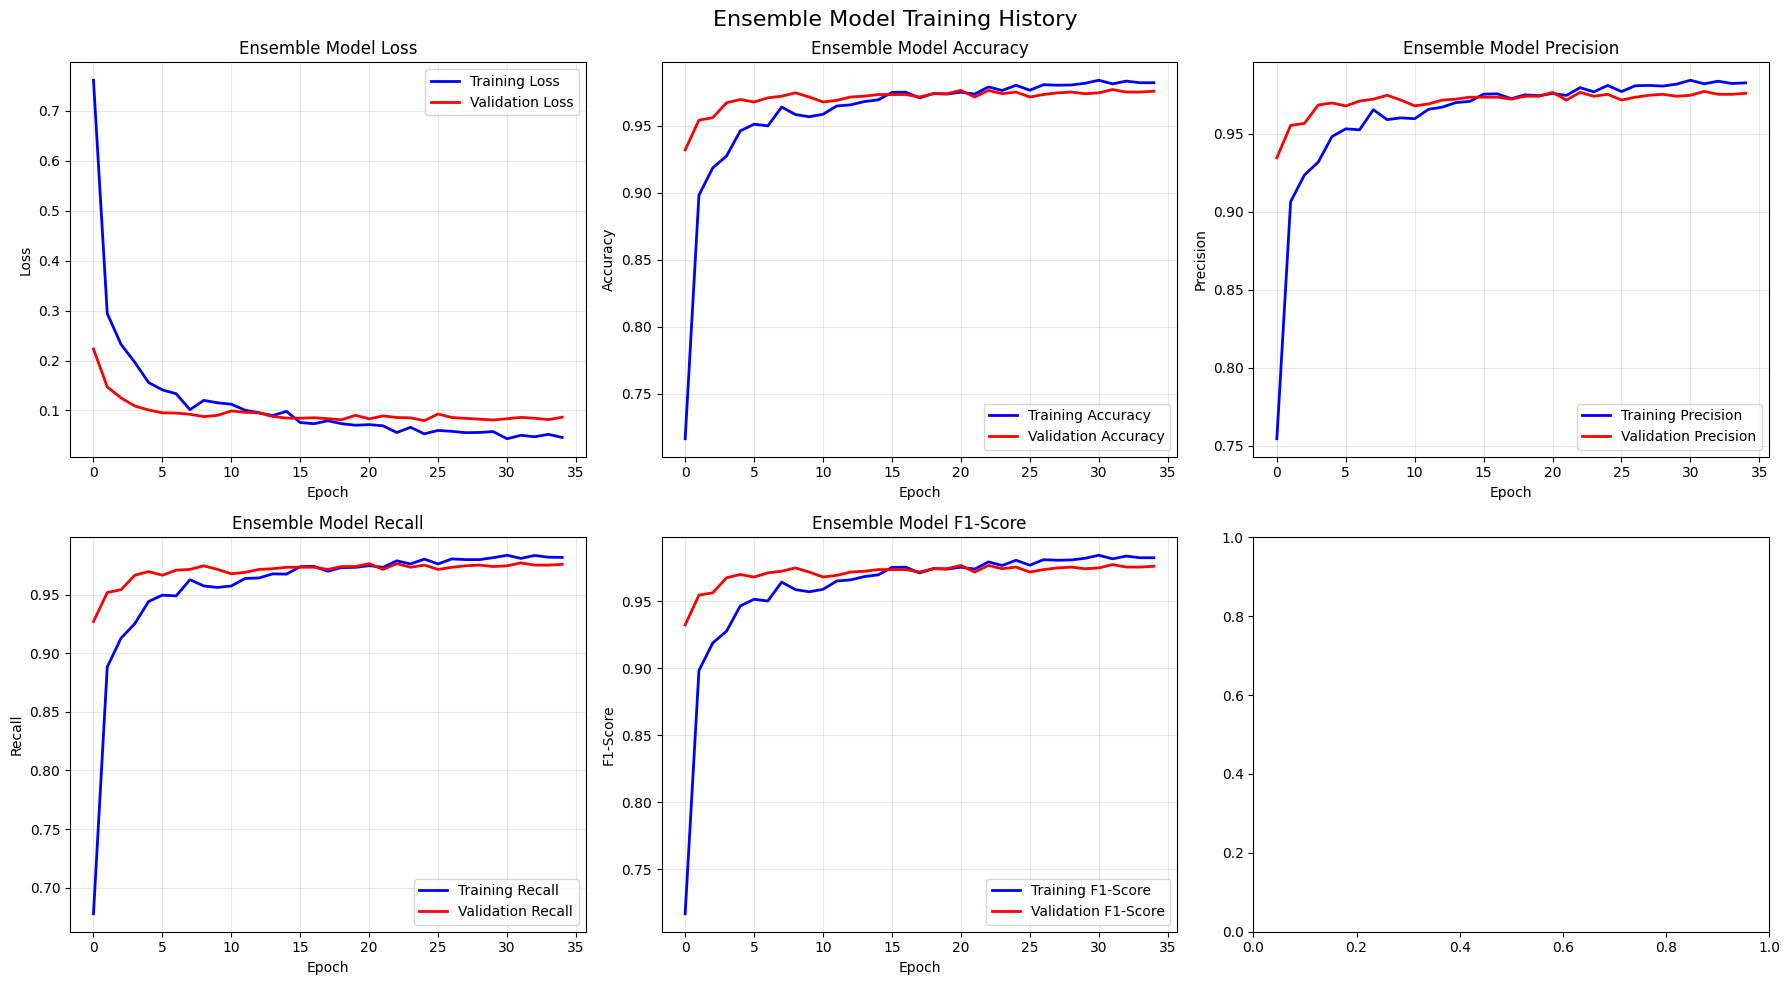

In [29]:
plot_training_history(history)

In [30]:
# -------------------------------
# Evaluation Functions
# -------------------------------
def evaluate_ensemble_model(model, test_set, class_names):
    """Comprehensive ensemble model evaluation"""
    print("\n🧪 Evaluating Ensemble Model Performance...")
    
    # Basic evaluation
    print("📊 Running Ensemble Evaluation...")
    evaluation_results = model.evaluate(test_set, verbose=1)
    
    # Create a dictionary with metric names and values
    metric_names = ['loss', 'accuracy', 'precision', 'recall', 'f1_score']
    eval_dict = dict(zip(metric_names, evaluation_results))
    
    print("\n📋 Ensemble Evaluation Results:")
    for metric, value in eval_dict.items():
        print(f"   {metric.capitalize()}: {value:.4f}")
    
    # Predictions for detailed analysis
    print("\n🔍 Generating Ensemble Predictions...")
    y_true = []
    y_pred = []
    y_probs = []
    
    # Also collect predictions from individual models if available
    individual_predictions = []
    
    for images, labels in test_set:
        # Get true labels
        true_labels = tf.argmax(labels, axis=1)
        y_true.extend(true_labels.numpy())
        
        # Get ensemble predictions
        predictions = model.predict(images, verbose=0)
        pred_labels = tf.argmax(predictions, axis=1)
        y_pred.extend(pred_labels.numpy())
        y_probs.extend(predictions)
    
    # Convert to numpy arrays
    y_true = np.array(y_true)
    y_pred = np.array(y_pred)
    y_probs = np.array(y_probs)
    
    # Classification Report
    print("\n📋 Detailed Classification Report:")
    print(classification_report(y_true, y_pred, target_names=class_names))
    
    # Confusion Matrix
    plot_confusion_matrix(y_true, y_pred, class_names)
    
    # Calibration curve
    plot_calibration_curve(y_true, y_probs, class_names)
    
    # Model contributions (if ensemble has component models)
    if hasattr(model, 'component_models'):
        variances = plot_model_contributions(model, test_set)
        print(f"\n📈 Model Contribution Analysis:")
        for name, var in zip(model.model_names, variances):
            print(f"   {name}: Variance = {var:.4f}")
    
    return y_true, y_pred, y_probs, eval_dict

In [31]:
def plot_confusion_matrix(y_true, y_pred, class_names):
    """Plot detailed confusion matrix"""
    cm = confusion_matrix(y_true, y_pred)
    
    plt.figure(figsize=(10, 8))
    
    # Plot regular confusion matrix
    plt.subplot(1, 2, 1)
    sns.heatmap(cm, annot=True, fmt='d', cmap='Blues', 
                xticklabels=class_names, 
                yticklabels=class_names)
    plt.title('Ensemble Confusion Matrix\n(Counts)')
    plt.xlabel('Predicted Label')
    plt.ylabel('True Label')
    
    # Calculate normalized confusion matrix
    plt.subplot(1, 2, 2)
    cm_normalized = cm.astype('float') / cm.sum(axis=1)[:, np.newaxis]
    sns.heatmap(cm_normalized, annot=True, fmt='.2f', cmap='Blues',
                xticklabels=class_names, 
                yticklabels=class_names)
    plt.title('Ensemble Confusion Matrix\n(Normalized)')
    plt.xlabel('Predicted Label')
    plt.ylabel('True Label')
    
    plt.tight_layout()
    plt.show()

In [32]:
def plot_calibration_curve(y_true, y_probs, class_names):
    """Plot calibration curves for ensemble predictions"""
    print("\n📊 Plotting Calibration Curves...")
    
    n_classes = len(class_names)
    fig, axes = plt.subplots(2, 2, figsize=(12, 10))
    axes = axes.flatten()
    
    for i in range(n_classes):
        # Get binary labels for this class
        y_true_binary = (y_true == i).astype(int)
        y_prob_class = y_probs[:, i]
        
        # Compute calibration curve
        prob_true, prob_pred = calibration_curve(y_true_binary, y_prob_class, n_bins=10)
        
        # Plot calibration curve
        axes[i].plot(prob_pred, prob_true, marker='o', linewidth=2, label='Ensemble')
        axes[i].plot([0, 1], [0, 1], 'k--', label='Perfectly Calibrated')
        axes[i].set_xlabel('Predicted Probability')
        axes[i].set_ylabel('True Probability')
        axes[i].set_title(f'Calibration: {class_names[i]}')
        axes[i].legend()
        axes[i].grid(True, alpha=0.3)
        
        # Calculate Brier score
        brier_score = np.mean((y_prob_class - y_true_binary) ** 2)
        axes[i].text(0.05, 0.85, f'Brier: {brier_score:.3f}', 
                    transform=axes[i].transAxes, fontsize=10,
                    bbox=dict(boxstyle='round', facecolor='wheat', alpha=0.5))
    
    plt.suptitle('Ensemble Model Calibration Curves', fontsize=14)
    plt.tight_layout()
    plt.show()

In [33]:
def compare_individual_models(ensemble_model, test_set, class_names):
    """Compare performance of individual models vs ensemble"""
    print("\n🔬 Comparing Individual Models vs Ensemble...")
    
    if not hasattr(ensemble_model, 'component_models'):
        print("⚠️ Individual model comparison not available")
        return
    
    # Prepare to collect metrics
    model_names = ensemble_model.model_names
    accuracies = []
    f1_scores = []
    
    # Evaluate each individual model
    for i, (model, name) in enumerate(zip(ensemble_model.component_models, model_names)):
        print(f"\n   Evaluating {name}...")
        
        # Add classification head to model
        x = model.output
        x = tf.keras.layers.Dense(128, activation='relu')(x)
        x = tf.keras.layers.Dropout(0.3)(x)
        outputs = tf.keras.layers.Dense(CONFIG['num_classes'], activation='softmax')(x)
        individual_model = tf.keras.Model(inputs=model.input, outputs=outputs)
        
        # Compile and evaluate
        individual_model.compile(
            optimizer='adam',
            loss='categorical_crossentropy',
            metrics=['accuracy', tf.keras.metrics.F1Score(average='weighted')]
        )
        
        # Evaluate
        results = individual_model.evaluate(test_set, verbose=0)
        accuracies.append(results[1])
        f1_scores.append(results[2])
        
        print(f"     Accuracy: {results[1]:.4f}")
        print(f"     F1-Score: {results[2]:.4f}")
    
    # Plot comparison
    fig, axes = plt.subplots(1, 2, figsize=(14, 6))
    
    # Accuracy comparison
    x_pos = np.arange(len(model_names))
    axes[0].bar(x_pos, accuracies, color=['#FF6B6B', '#4ECDC4', '#45B7D1'])
    axes[0].set_xlabel('Model')
    axes[0].set_ylabel('Accuracy')
    axes[0].set_title('Individual Model Accuracy')
    axes[0].set_xticks(x_pos)
    axes[0].set_xticklabels(model_names, rotation=45)
    axes[0].grid(True, axis='y', alpha=0.3)
    
    # Add value labels
    for i, acc in enumerate(accuracies):
        axes[0].text(i, acc + 0.01, f'{acc:.3f}', ha='center', va='bottom')
    
    # F1-Score comparison
    axes[1].bar(x_pos, f1_scores, color=['#FF6B6B', '#4ECDC4', '#45B7D1'])
    axes[1].set_xlabel('Model')
    axes[1].set_ylabel('F1-Score')
    axes[1].set_title('Individual Model F1-Score')
    axes[1].set_xticks(x_pos)
    axes[1].set_xticklabels(model_names, rotation=45)
    axes[1].grid(True, axis='y', alpha=0.3)
    
    # Add value labels
    for i, f1 in enumerate(f1_scores):
        axes[1].text(i, f1 + 0.01, f'{f1:.3f}', ha='center', va='bottom')
    
    plt.tight_layout()
    plt.show()
    
    return dict(zip(model_names, zip(accuracies, f1_scores)))


7️⃣ STEP 7: Individual Model Comparison
------------------------------

🔬 Comparing Individual Models vs Ensemble...

   Evaluating EfficientNetB0...


2026-03-01 08:32:47.999275: E external/local_xla/xla/stream_executor/cuda/cuda_timer.cc:86] Delay kernel timed out: measured time has sub-optimal accuracy. There may be a missing warmup execution, please investigate in Nsight Systems.
2026-03-01 08:32:48.140188: E external/local_xla/xla/stream_executor/cuda/cuda_timer.cc:86] Delay kernel timed out: measured time has sub-optimal accuracy. There may be a missing warmup execution, please investigate in Nsight Systems.
2026-03-01 08:32:48.470568: E external/local_xla/xla/stream_executor/cuda/cuda_timer.cc:86] Delay kernel timed out: measured time has sub-optimal accuracy. There may be a missing warmup execution, please investigate in Nsight Systems.
2026-03-01 08:32:48.611248: E external/local_xla/xla/stream_executor/cuda/cuda_timer.cc:86] Delay kernel timed out: measured time has sub-optimal accuracy. There may be a missing warmup execution, please investigate in Nsight Systems.
2026-03-01 08:32:49.324464: E external/local_xla/xla/stream_

     Accuracy: 0.2134
     F1-Score: 0.2116

   Evaluating MobileNetV2...


2026-03-01 08:33:07.947221: E external/local_xla/xla/stream_executor/cuda/cuda_timer.cc:86] Delay kernel timed out: measured time has sub-optimal accuracy. There may be a missing warmup execution, please investigate in Nsight Systems.
2026-03-01 08:33:08.087715: E external/local_xla/xla/stream_executor/cuda/cuda_timer.cc:86] Delay kernel timed out: measured time has sub-optimal accuracy. There may be a missing warmup execution, please investigate in Nsight Systems.
2026-03-01 08:33:08.226238: E external/local_xla/xla/stream_executor/cuda/cuda_timer.cc:86] Delay kernel timed out: measured time has sub-optimal accuracy. There may be a missing warmup execution, please investigate in Nsight Systems.


     Accuracy: 0.2369
     F1-Score: 0.1927

   Evaluating ResNet50...
     Accuracy: 0.2252
     F1-Score: 0.2291


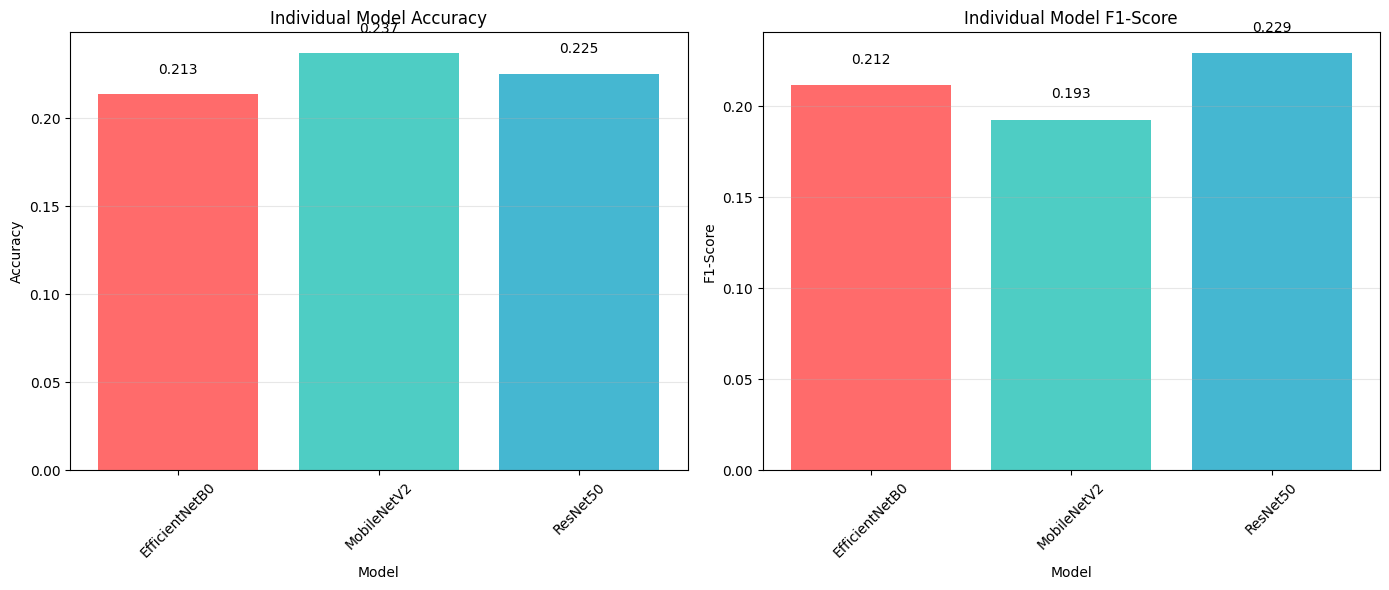

In [34]:
print("\n7️⃣ STEP 7: Individual Model Comparison")
print("-" * 30)
    
# Compare individual models vs ensemble
individual_results = compare_individual_models(model, test_set, class_names)


🧪 Evaluating Ensemble Model Performance...
📊 Running Ensemble Evaluation...
51/51 ━━━━━━━━━━━━━━━━━━━━ 17s 330ms/step - accuracy: 0.9805 - f1_score: 0.9841 - loss: 0.0684 - precision: 0.9805 - recall: 0.9805

📋 Ensemble Evaluation Results:
   Loss: 0.0745
   Accuracy: 0.9766
   Precision: 0.9766
   Recall: 0.9766
   F1_score: 0.9766

🔍 Generating Ensemble Predictions...

📋 Detailed Classification Report:
                      precision    recall  f1-score   support

Corona Virus Disease       0.99      0.99      0.99       407
              Normal       0.96      0.97      0.96       404
           Pneumonia       0.96      0.95      0.96       402
        Tuberculosis       1.00      1.00      1.00       408

            accuracy                           0.98      1621
           macro avg       0.98      0.98      0.98      1621
        weighted avg       0.98      0.98      0.98      1621



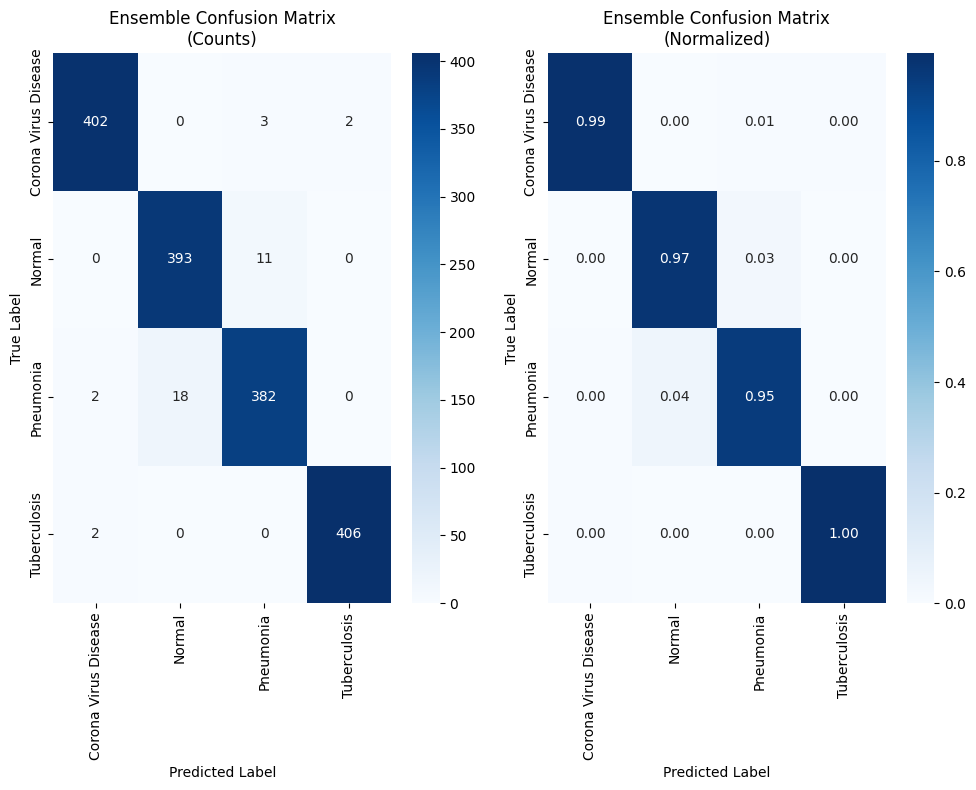


📊 Plotting Calibration Curves...


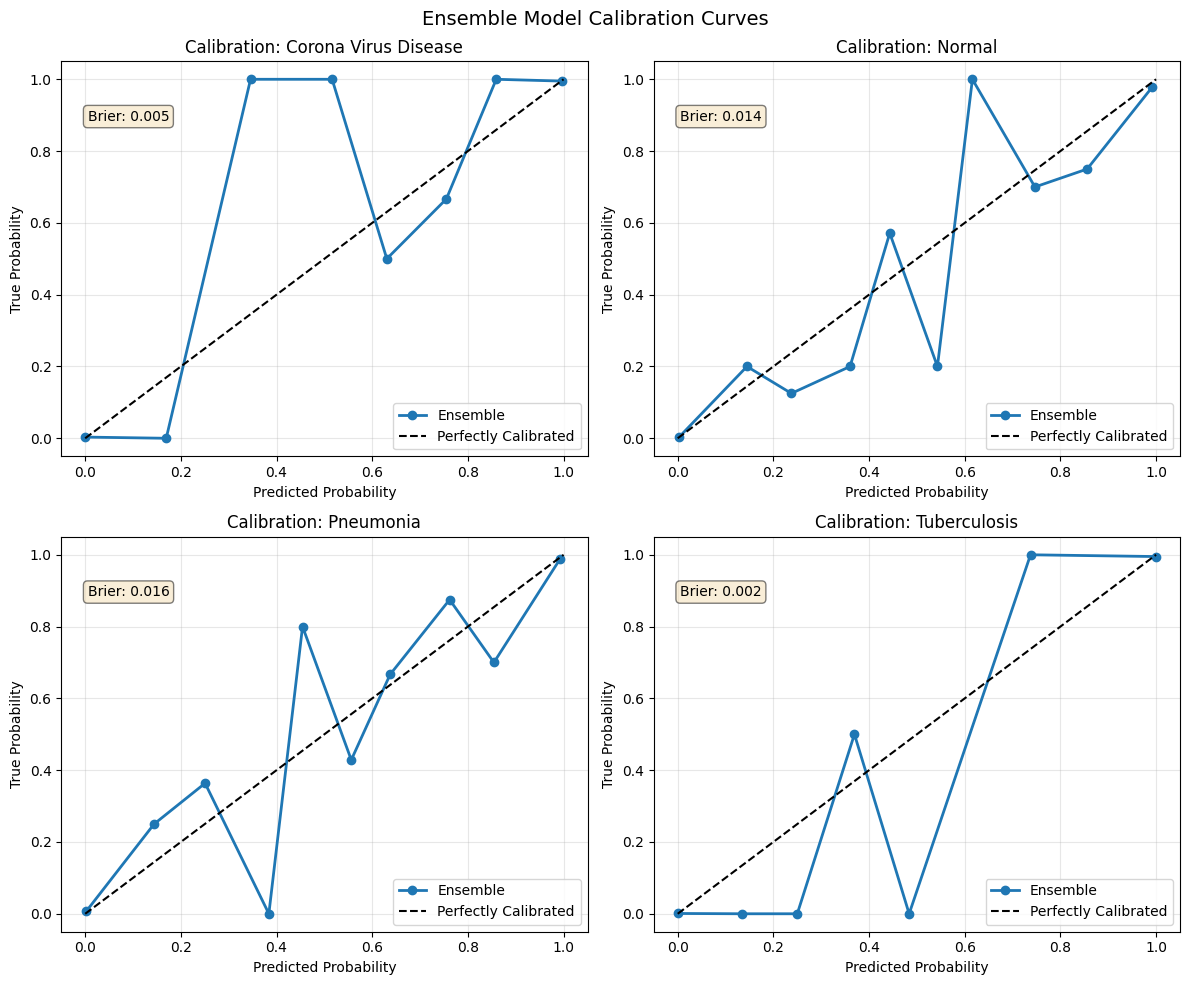


📊 Analyzing Model Contributions...


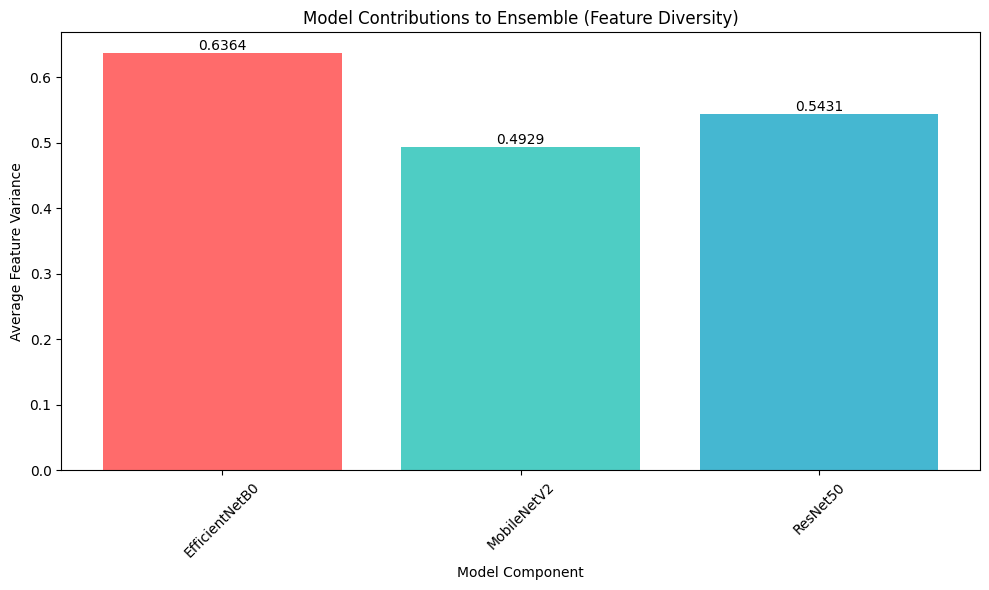


📈 Model Contribution Analysis:
   EfficientNetB0: Variance = 0.6364
   MobileNetV2: Variance = 0.4929
   ResNet50: Variance = 0.5431


In [35]:
y_true, y_pred, y_probs, eval_results = evaluate_ensemble_model(model, test_set, class_names)

In [36]:
print("🎉 Ensemble Model Training Completed Successfully!")
print(f"📊 Ensemble Test Accuracy: {eval_results['accuracy']:.2%}")
print(f"📊 Ensemble Test F1-Score: {eval_results['f1_score']:.2%}")

🎉 Ensemble Model Training Completed Successfully!
📊 Ensemble Test Accuracy: 97.66%
📊 Ensemble Test F1-Score: 97.66%


In [37]:
# Display model summary
print(f"\n📋 Ensemble Model Summary:")
if hasattr(model, 'model_names'):
    for i, name in enumerate(model.model_names):
        print(f"   Model {i+1}: {name}")
print(f"   Training Strategy: {CONFIG['ensemble_weights']} weighting")
print(f"   Training Epochs: {len(history.history['loss'])}")
print(f"   Final Learning Rate: {model.optimizer.learning_rate.numpy():.2e}")


📋 Ensemble Model Summary:
   Model 1: EfficientNetB0
   Model 2: MobileNetV2
   Model 3: ResNet50
   Training Strategy: learned weighting
   Training Epochs: 35
   Final Learning Rate: 3.13e-05


In [38]:
# Show improvement over individual models
if individual_results:
    print(f"\n📈 Ensemble Advantage:")
    best_individual_acc = max([acc for acc, _ in individual_results.values()])
    best_individual_f1 = max([f1 for _, f1 in individual_results.values()])
        
    acc_improvement = eval_results['accuracy'] - best_individual_acc
    f1_improvement = eval_results['f1_score'] - best_individual_f1
        
print(f"   Accuracy improvement: {acc_improvement:.4f} over best individual model")
print(f"   F1-Score improvement: {f1_improvement:.4f} over best individual model")


📈 Ensemble Advantage:
   Accuracy improvement: 0.7397 over best individual model
   F1-Score improvement: 0.7475 over best individual model


In [39]:
def predict_with_ensemble(model, image_path, class_names):
    """Predict a single image with ensemble model"""
    img = tf.keras.preprocessing.image.load_img(image_path, target_size=CONFIG['image_size'])
    img_array = tf.keras.preprocessing.image.img_to_array(img)
    
    # Note: Ensemble model handles preprocessing internally for each component
    img_array = tf.expand_dims(img_array, 0)  # Create batch dimension
    
    # Get predictions
    predictions = model.predict(img_array)
    predicted_class_idx = tf.argmax(predictions[0]).numpy()
    predicted_class = class_names[predicted_class_idx]
    confidence = np.max(predictions[0])
    
    # Create ensemble visualization
    print(f"\n🎯 Ensemble Model Prediction:")
    print(f"   Combined prediction from {len(model.model_names) if hasattr(model, 'model_names') else 3} models")
    
    # Plot the image with prediction
    plt.figure(figsize=(12, 4))
    
    plt.subplot(1, 3, 1)
    plt.imshow(img)
    plt.title(f"Input Image\nTrue: {os.path.basename(os.path.dirname(image_path))}")
    plt.axis('off')
    
    plt.subplot(1, 3, 2)
    # Create a bar plot of probabilities
    colors = ['royalblue' if i == predicted_class_idx else 'lightgray' for i in range(len(class_names))]
    plt.barh(class_names, predictions[0], color=colors)
    plt.xlabel('Probability')
    plt.title(f'Ensemble Probabilities\nPredicted: {predicted_class}')
    plt.xlim([0, 1])
    
    plt.subplot(1, 3, 3)
    # Show ensemble info
    if hasattr(model, 'model_names'):
        model_list = '\n'.join([f'• {name}' for name in model.model_names])
    else:
        model_list = '• EfficientNetB0\n• MobileNetV2\n• ResNet50'
    
    plt.text(0.1, 0.8, f'ENSEMBLE MODEL', fontsize=12, fontweight='bold', color='royalblue')
    plt.text(0.1, 0.7, f'Components:', fontsize=10, fontweight='bold')
    plt.text(0.1, 0.55, model_list, fontsize=9)
    plt.text(0.1, 0.3, f'Final Prediction:', fontsize=10, fontweight='bold')
    plt.text(0.1, 0.25, f'{predicted_class}', fontsize=11, color='royalblue')
    plt.text(0.1, 0.15, f'Confidence: {confidence:.2%}', fontsize=10)
    plt.axis('off')
    
    plt.suptitle(f'Ensemble Model Decision', fontsize=14)
    plt.tight_layout()
    plt.show()
    
    return predicted_class, confidence

🔍 Testing ensemble prediction on: 00030389_012.png


2026-03-01 08:35:27.551470: E external/local_xla/xla/stream_executor/cuda/cuda_timer.cc:86] Delay kernel timed out: measured time has sub-optimal accuracy. There may be a missing warmup execution, please investigate in Nsight Systems.
2026-03-01 08:35:27.686151: E external/local_xla/xla/stream_executor/cuda/cuda_timer.cc:86] Delay kernel timed out: measured time has sub-optimal accuracy. There may be a missing warmup execution, please investigate in Nsight Systems.
2026-03-01 08:35:28.377291: E external/local_xla/xla/stream_executor/cuda/cuda_timer.cc:86] Delay kernel timed out: measured time has sub-optimal accuracy. There may be a missing warmup execution, please investigate in Nsight Systems.
2026-03-01 08:35:28.511644: E external/local_xla/xla/stream_executor/cuda/cuda_timer.cc:86] Delay kernel timed out: measured time has sub-optimal accuracy. There may be a missing warmup execution, please investigate in Nsight Systems.
2026-03-01 08:35:32.495480: E external/local_xla/xla/stream_

1/1 ━━━━━━━━━━━━━━━━━━━━ 19s 19s/step

🎯 Ensemble Model Prediction:
   Combined prediction from 3 models


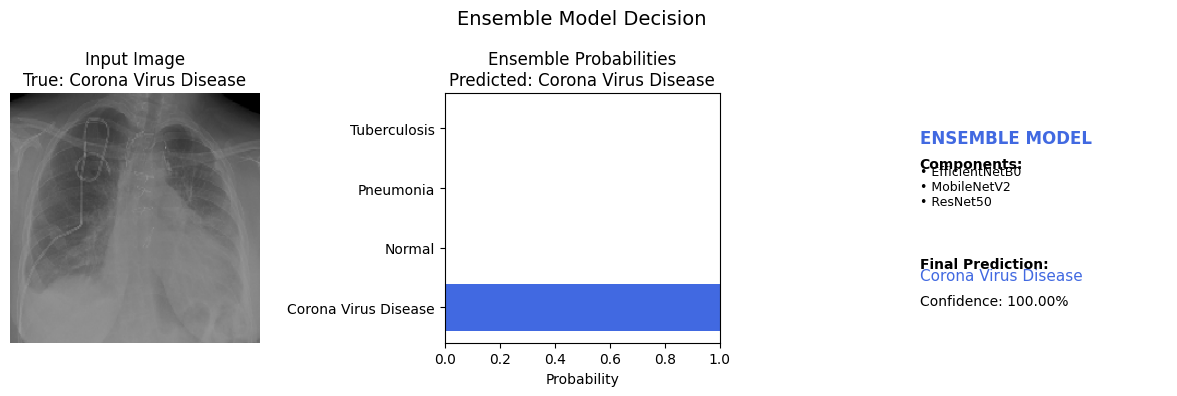

In [40]:
# Find a sample image from test set for demonstration
test_images_dir = os.path.join(test_path, class_names[0])
if os.path.exists(test_images_dir):
    sample_images = os.listdir(test_images_dir)
    if sample_images:
        sample_image_path = os.path.join(test_images_dir, sample_images[0])
print(f"🔍 Testing ensemble prediction on: {sample_images[0]}")
predicted_class, confidence = predict_with_ensemble(model, sample_image_path, class_names)

In [41]:
import tensorflow as tf
from tensorflow.keras.applications.mobilenet_v3 import preprocess_input
import numpy as np
import os

image_path = "/kaggle/input/epics-lung-disease-dataset/new-lung-disease-dataset/test/Tuberculosis/Tuberculosis-103.jpg"
img = tf.keras.utils.load_img(image_path, target_size=(224,224))
img

x = tf.keras.utils.img_to_array(img)
x = np.expand_dims(x, axis=0)
x = preprocess_input(x)
x.shape

(1, 224, 224, 3)

In [42]:
pred = model.predict(x)

class_name=['Corona Virus Disease','Normal','Pneumonia', 'Tuberculosis']
result_index = np.argmax(pred)
print("Model Prediction: ", class_name[result_index])

1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 78ms/step
Model Prediction:  Tuberculosis
